# Dataset Sintético de Evasão Escolar

Este notebook gera um dataset sintético com base em variáveis relacionadas à evasão escolar no ensino público do Distrito Federal. As variáveis foram definidas previamente e incluem dados do estudante, família, comunidade, escola e professores.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Configurações iniciais
n_alunos = 1000  # número de registros

In [12]:
sexos = ['Masculino', 'Feminino', 'Outro']
etapas = ['5º ano', '6º ano', '7º ano', '8º ano', '9º ano', '1ª série EM', '2ª série EM', '3ª série EM']
niveis_socioeconomicos = [f'N{i}' for i in range(1, 8)]
apoio_familiar_vals = ['Alto', 'Médio', 'Baixo']
comportamento_vals = ['Bom', 'Regular', 'Ruim']
aceitacao_vals = ['Alta', 'Média', 'Baixa']
expectativa_vals = ['Alta', 'Média', 'Baixa']
engajamento_vals = ['Alto', 'Moderado', 'Baixo']
infraestrutura_vals = ['Boa', 'Regular', 'Ruim']
material_vals = ['Completa', 'Parcial', 'Insuficiente']
flex_pedagogica_vals = ['Alta', 'Média', 'Baixa']
qualidade_pedagogica_vals = ['Boa', 'Regular', 'Ruim']

In [13]:
def gerar_idade():
    return np.random.randint(10, 19)

def gerar_renda():
    return round(np.random.lognormal(mean=6.5, sigma=0.5), 2)

def gerar_frequencia():
    return round(np.random.uniform(50, 100), 1)

def gerar_nota():
    return round(np.random.normal(6.5, 1.5), 1)

def gerar_distancia():
    return round(abs(np.random.normal(2, 1)), 1)


In [14]:
# Criação do DataFrame
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'sexo': np.random.choice(sexos, n_alunos),
    'idade': [gerar_idade() for _ in range(n_alunos)],
    'etapa_ensino': np.random.choice(etapas, n_alunos),
    'renda_familiar': [gerar_renda() for _ in range(n_alunos)],
    'nivel_socioeconomico': np.random.choice(niveis_socioeconomicos, n_alunos),
    'frequencia_escolar': [gerar_frequencia() for _ in range(n_alunos)],
    'notas_medias': [gerar_nota() for _ in range(n_alunos)],
    'repetente': np.random.choice([True, False], n_alunos, p=[0.2, 0.8]),
    'trabalha': np.random.choice([True, False], n_alunos, p=[0.15, 0.85]),
    'trabalho_domestico_excessivo': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'problemas_de_saude': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'violencia_domestica': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'gravidez_na_adolescencia': np.random.choice([True, False], n_alunos, p=[0.03, 0.97]),
    'apoio_familiar': np.random.choice(apoio_familiar_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'comportamento_em_sala': np.random.choice(comportamento_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'aceitacao_pelos_pares': np.random.choice(aceitacao_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'necessita_assistencia_social': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'expectativa_retorno': np.random.choice(expectativa_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'fator_desencadeador_presente': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'distancia_da_escola_km': [gerar_distancia() for _ in range(n_alunos)],
    'violencia_na_comunidade': np.random.choice([True, False], n_alunos, p=[0.2, 0.8]),
    'engajamento_com_a_escola': np.random.choice(engajamento_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'infraestrutura_escolar': np.random.choice(infraestrutura_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'disponibilidade_material_didatico': np.random.choice(material_vals, n_alunos, p=[0.6, 0.3, 0.1]),
    'flexibilidade_pedagogica': np.random.choice(flex_pedagogica_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'qualidade_pedagogica_percebida': np.random.choice(qualidade_pedagogica_vals, n_alunos, p=[0.5, 0.3, 0.2])
})

# Pontuação de risco
df['pontuacao_risco'] = (
    (100 - df['frequencia_escolar']) / 100 * 0.3 +
    (10 - df['notas_medias']) / 10 * 0.3 +
    df['repetente'].astype(int) * 0.1 +
    df['trabalha'].astype(int) * 0.1 +
    df['violencia_domestica'].astype(int) * 0.2
)
df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()

# Evasão confirmada
df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]


In [15]:
df.head()

,id_aluno,sexo,idade,etapa_ensino,renda_familiar,nivel_socioeconomico,frequencia_escolar,notas_medias,repetente,trabalha,...,fator_desencadeador_presente,distancia_da_escola_km,violencia_na_comunidade,engajamento_com_a_escola,infraestrutura_escolar,disponibilidade_material_didatico,flexibilidade_pedagogica,qualidade_pedagogica_percebida,pontuacao_risco,evasao_confirmada
0,1,Feminino,13,1ª série EM,419.15,N7,82.9,8.2,False,False,...,False,4.0,False,Moderado,Ruim,Completa,Baixa,Boa,0.163840,False
1,2,Masculino,17,1ª série EM,1966.50,N5,61.8,5.9,True,False,...,False,1.9,False,Moderado,Boa,Completa,Média,Boa,0.525284,True
2,3,Feminino,11,5º ano,413.19,N1,99.9,5.7,False,False,...,False,2.3,False,Alto,Boa,Parcial,Alta,Ruim,0.201183,False
3,4,Feminino,17,3ª série EM,827.04,N1,93.3,7.1,False,False,...,False,1.7,False,Alto,Boa,Completa,Média,Regular,0.166641,False
4,5,Feminino,10,8º ano,739.40,N6,99.2,7.4,True,True,...,False,1.6,True,Moderado,Boa,Parcial,Baixa,Ruim,0.436284,False


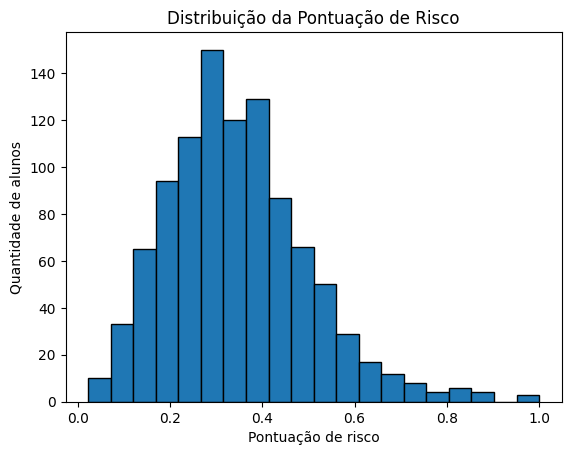

In [16]:
# Visualização da distribuição da pontuação de risco
plt.hist(df['pontuacao_risco'], bins=20, edgecolor='black')
plt.title('Distribuição da Pontuação de Risco')
plt.xlabel('Pontuação de risco')
plt.ylabel('Quantidade de alunos')
plt.show()

In [17]:
# Salvar dataset em CSV
df.to_csv('dataset_evasao_sintetico.csv', index=False)
print('Dataset salvo como dataset_evasao_sintetico.csv')

Dataset salvo como dataset_evasao_sintetico.csv
